## Petrol Stations Project : Exploration and Data Preprocessing

---
This project focuses on the analysis of a dataset containing information about petrol stations, including fuel prices and other relevant attributes. The goal is to explore the data, identify patterns, and prepare it for further analysis or modeling.

Libraries such as pandas, matplotlib, scikit-learn, and AutoViz are utilized for data manipulation, visualization, and preprocessing tasks.

**Author:**
 👨‍💻    [Anabel Díaz](https://github.com/rubiwan)

## Initial Data Exploration
---
### 1. Understanding the dataset
- Dataset loading into a pandas DataFrame.
- Contains information about petrol stations, including location, type of service, and fuel prices.
- Display structure and content.

In [1]:
import pandas as pd
from nltk.corpus.europarl_raw import english

df = pd.read_csv("gii32_ act1_precios_carburantes_24.csv")
df.head()

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
0,ALBACETE,ABENGIBRE,ABENGIBRE,2250,"AVENIDA CASTILLA LA MANCHA, 26","1,529","1,419",P,A,Nº 10.935
1,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 5",NaN,"1,560",R,A,CEPSA
2,ALBACETE,ALBACETE,ALBACETE,2001,"CALLE FEDERICO GARCIA LORCA, 1","1,409","1,399",P,D,PLENOIL
3,ALBACETE,ALBACETE,ALBACETE,2001,"AVENIDA 1º DE MAYO, S/N","1,539","1,489",P,A,CARREFOUR
4,ALBACETE,ALBACETE,ALBACETE,2001,CALLE PRINCIPE DE ASTURIAS (POLÍGONO DE ROMICA...,"1,549","1,549",P,A,BP ROMICA


### 2. Number of rows and columns
- Explore the dataset to understand its structure and dimensions.
- This is fundamental for planning the analysis and data preprocessing steps.

In [2]:
df.shape

(11865, 10)

### 3. Column names
- Review the column names for a better understanding of the data
- Identify any potential issues with naming conventions that may need to be addressed during preprocessing.

In [3]:
df.columns

Index(['Provincia', 'Municipio', 'Localidad', 'Código postal', 'Dirección',
       'Precio gasolina 95 E5', 'Precio gasóleo A', 'Tipo venta',
       'Tipo servicio', 'Rótulo'],
      dtype='object')

*Dataset contains information about petrol stations, including location (Province, Municipality), type of service, postal code, and fuel prices (Precio gasolina 95 E5, Precio gasóleo A).*

### 4. Missing values and data types
- Check for missing values in the dataset to identify any gaps in the data that may need to be addressed.
- Review the data types of each column to ensure they are appropriate for analysis and modeling.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11865 entries, 0 to 11864
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Provincia              11865 non-null  object
 1   Municipio              11865 non-null  object
 2   Localidad              11865 non-null  object
 3   Código postal          11865 non-null  int64 
 4   Dirección              11865 non-null  object
 5   Precio gasolina 95 E5  10702 non-null  object
 6   Precio gasóleo A       11498 non-null  object
 7   Tipo venta             11865 non-null  object
 8   Tipo servicio          10803 non-null  object
 9   Rótulo                 11865 non-null  object
dtypes: int64(1), object(9)
memory usage: 927.1+ KB


*We observe that the price columns are stored as text due to the use of commas as decimal separators, which will require further preprocessing to convert them into numerical data types for analysis and modeling.*

## Data Preprocessing
---
### 5. Statical summary.
- Correct understanding the distribution and characteristics of the data, which can inform subsequent preprocessing and analysis steps.

In [5]:
df.describe(include='all')

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
count,11865,11865,11865,11865.000000,11865,10702,11498,11865,10803,11865
unique,52,3415,4228,NaN,11554,414,438,3,3,4025
top,MADRID,MADRID,MADRID,NaN,"AVENIDA ANDALUCIA, S/N","1,559","1,569",P,A,REPSOL
freq,852,241,241,NaN,11,568,642,11105,8098,2733
mean,NaN,NaN,NaN,25413.898272,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,14476.124512,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1002.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,12006.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,27246.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,38002.000000,NaN,NaN,NaN,NaN,NaN,NaN


### 6. Filter by column.
- Filter the dataset to include only rows where the "Provincia" column has a determinated value.
- This allows us to focus our analysis on a specific region, which can be useful for understanding local trends and patterns in petrol prices.

In [6]:
df_madrid = df[df['Provincia'] == 'MADRID']
df_madrid.head().head()

,Provincia,Municipio,Localidad,Código postal,Dirección,Precio gasolina 95 E5,Precio gasóleo A,Tipo venta,Tipo servicio,Rótulo
6484,MADRID,AJALVIR,AJALVIR,28864,CARRETERA M-114 KM. 1,"1,599","1,579",P,A,REPSOL
6485,MADRID,AJALVIR,AJALVIR,28864,"CARRETERA M-114 KM. 0,7","1,599","1,579",P,A,REPSOL
6486,MADRID,AJALVIR,AJALVIR,28864,"CAMINO TORREJON, 4","1,479","1,389",P,D,PLENOIL
6487,MADRID,ÁLAMO (EL),ALAMO (EL),28607,"CTRA. LOCAL M-404 km 3,640","1,464","1,339",P,A,"E.S. EL ALAMO, S.L."
6488,MADRID,ÁLAMO (EL),ALAMO (EL),28607,"AVENIDA MADRID, 2","1,459","1,349",P,D,PLENOIL


*We have selected the province of Madrid due to its high number of records, which allows for a more representative statistical analysis.*

### 7. Confirm column names
- After filtering the dataset, it's important to confirm that the column names are still intact and correctly labeled.
- This ensures that subsequent analysis and operations on the dataset can be performed without issues related to column

In [7]:
df_madrid.columns

Index(['Provincia', 'Municipio', 'Localidad', 'Código postal', 'Dirección',
       'Precio gasolina 95 E5', 'Precio gasóleo A', 'Tipo venta',
       'Tipo servicio', 'Rótulo'],
      dtype='object')

### 8. Managing new dataset.
- Determines the shape of the subset after filtering by the "Provincia" column.

In [8]:
df_madrid.shape

(852, 10)

### 9. Price analysis.
- We select two columns related to petrol prices, "Precio Gasolina 95 E5" and "Precio gasóleo A", to analyze their statistical properties.
- This analysis can provide insights into the distribution, central tendency, and variability of petrol prices in the selected region.

In [9]:
df_precios = df_madrid[['Precio gasolina 95 E5', 'Precio gasóleo A']].copy()

*We have created a new DataFrame, df_precios, that contains only the price columns which are relevant for our analysis. This allows us to focus on the price data and perform specific analyses related to petrol prices in Madrid without the distraction of other columns that may not be relevant to this particular aspect of the dataset.*


### 10. Data cleaning.
- As we detected before, price columns contain values with commas as decimal separators, which can cause issues when performing numerical analysis.

#### 10.1. Replace commas with dots.
- We replace the commas with dots in the price columns to ensure that the values are in a format that can be correctly interpreted as numerical data for analysis and modeling purposes.

In [10]:
df_precios['Precio gasolina 95 E5'] = df_precios['Precio gasolina 95 E5'].str.replace(',', '.')
df_precios['Precio gasóleo A'] = df_precios['Precio gasóleo A'].str.replace(',', '.')

#### 10.2. Convert to float.
- After replacing the commas with dots, we convert the price columns to numeric data types to enable proper numerical analysis and modeling.
- This step is crucial for performing calculations, statistical analysis, and machine learning tasks on the petrol price data.

In [11]:
df_precios['Precio gasolina 95 E5'] = df_precios['Precio gasolina 95 E5'].astype(float)
df_precios['Precio gasóleo A'] = df_precios['Precio gasóleo A'].astype(float)

*Prices were stored as text due to the use of commas as decimal separators. We perform a conversion to numeric format to allow for statistical analysis.*

#### 10.3. Check for missing values.
- Null values in the price columns can lead to issues in analysis and modeling, so it's important to identify and address them appropriately. In this case, we will use imputation techniques to fill in the missing values, ensuring that our dataset is complete and ready for further analysis.

In [12]:
df_precios.isnull().sum()

Precio gasolina 95 E5    40
Precio gasóleo A         32
dtype: int64

#### 10.4. Imputation of missing values.
- Imputation using the mean of each variable is a common technique for handling missing values in numerical data. By replacing missing values with the mean, we can maintain the overall distribution of the data while ensuring that we have a complete dataset for analysis and modeling.

In [13]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

df_precios[['Precio gasolina 95 E5', 'Precio gasóleo A']] = imputer.fit_transform(
    df_precios[['Precio gasolina 95 E5', 'Precio gasóleo A']]
)

### 11. Statistical summary of price columns.
- After cleaning the price data, we perform a statistical summary to understand the distribution and characteristics of the petrol prices in the selected region.
- This summary can provide insights into the central tendency, variability, and overall distribution of the petrol prices, which can inform subsequent analysis and modeling steps.

In [14]:
df_precios.describe()

,Precio gasolina 95 E5,Precio gasóleo A
count,852.000000,852.000000
mean,1.560661,1.505422
std,0.072207,0.099597
min,1.389000,1.249000
25%,1.499000,1.428750
50%,1.589000,1.559000
75%,1.615000,1.579000
max,1.749000,1.709000


### 12. Graphical analysis of price distribution.
- We create histograms to visualize the distribution of the "Precio gasolina 95 E5" and "Precio gasóleo A" columns.
- This graphical analysis helps to identify patterns, skewness, and potential outliers in the petrol price data, providing a visual representation of the distribution of prices in the selected region.

### Histogram for "Precio gasolina 95 E5"

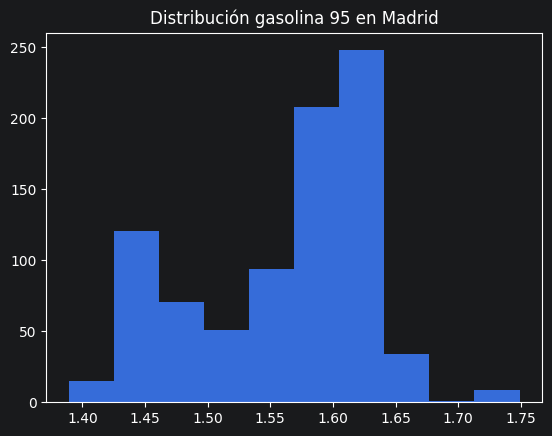

In [15]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

plt.hist(df_precios['Precio gasolina 95 E5'])
plt.title("Distribución gasolina 95 en Madrid")
plt.show()

### Histogram for "Precio gasóleo A"

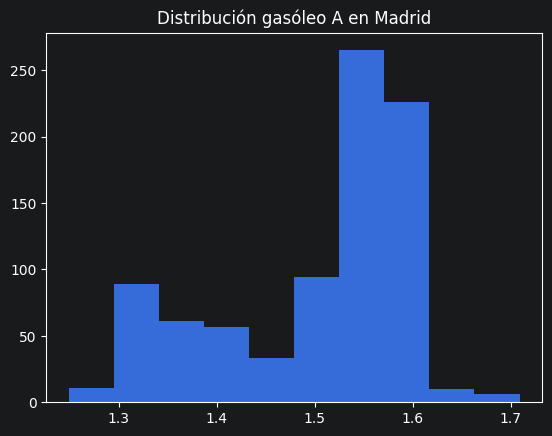

In [16]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

plt.hist(df_precios['Precio gasóleo A'])
plt.title("Distribución gasóleo A en Madrid")
plt.show()

*The histograms show the distribution of prices, with a concentration in certain ranges and moderate dispersion. This allows us to identify patterns in price behavior.*

### 13. Boxplot
Boxplots are a useful tool for visualizing the distribution of data, particularly for identifying the median, interquartile range, and potential outliers. By creating boxplots for the "Precio gasolina 95 E5" and "Precio gasóleo A" columns, we can gain insights into the central tendency and variability of petrol prices in the selected region, as well as identify any extreme values that may be present in the dataset.

#### Boxplot for "Precio gasolina 95 E5"

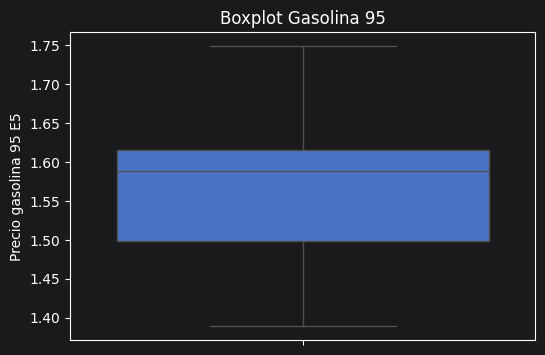

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=df_precios['Precio gasolina 95 E5'])
plt.title("Boxplot Gasolina 95")
plt.show()

#### Boxplot for "Precio gasóleo A"

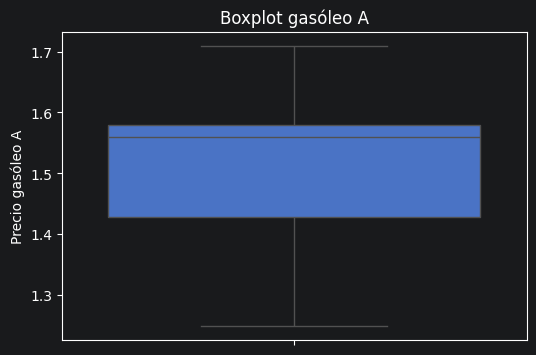

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=df_precios['Precio gasóleo A'])
plt.title("Boxplot gasóleo A")
plt.show()

#### Boxplot comparison between "Precio gasolina 95 E5" and "Precio gasóleo A"

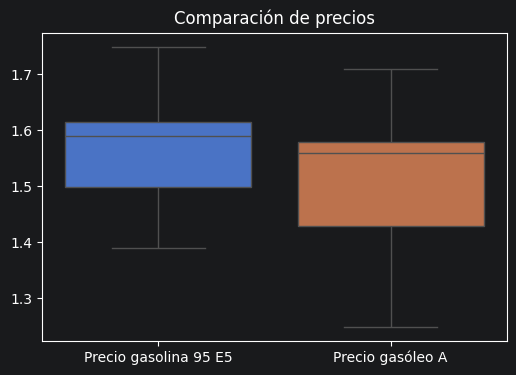

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(data=df_precios[['Precio gasolina 95 E5', 'Precio gasóleo A']])
plt.title("Comparación de precios")
plt.show()

This comparision shows that the price of gasoline is generally higher than that of diesel, with both maintaining a similar distribution. This suggests that while there may be differences in price levels, the overall variability and distribution patterns of both types of fuel are comparable in the selected region.

### 14. Correlation analysis.
- We calculate the correlation between the "Precio gasolina 95 E5" and "Precio gasóleo A" columns to understand the relationship between these two types of petrol prices in the selected region.

In [20]:
df_precios.corr()

,Precio gasolina 95 E5,Precio gasóleo A
Precio gasolina 95 E5,1.000000,0.922789
Precio gasóleo A,0.922789,1.000000


We observe a high positive correlation between the price of gasoline and diesel, indicating that both variables tend to vary together.

### 17. Normalization - Min-Max Scaling.
- We apply Min-Max Scaling for normalization, which scales the values of the price columns to a range between 0 and 1. This is particularly useful for machine learning models that are sensitive to the scale of the input data, as it helps to improve convergence and performance by ensuring that all features are on a similar scale.

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df_precios)
df_scaled = pd.DataFrame(df_scaled, columns=df_precios.columns)



### 18. Autoviz
- The use of AutoViz provides a comprehensive overview of the dataset, including visualizations and insights that can guide further analysis and modeling efforts. It helps to quickly identify trends, correlations, and potential issues in the data, making it a valuable tool for exploratory data analysis.

In [25]:

from autoviz.AutoViz_Class import AutoViz_Class


AV = AutoViz_Class()

df_autoviz = AV.AutoViz(
    "",
    depVar="",
    dfte=df,
    verbose=0
)

Shape of your Data Set loaded: (11865, 10)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    10 Predictors classified...
        No variables removed since no ID or low-information variables found in data set
There are 122 duplicate rows in your dataset
    Alert: Dropping duplicate rows can sometimes cause your column data types to change to object!
    All variables classified into correct types.


,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
Provincia,object,0.000000,0,,,13 rare categories: Too many to list. Group them into a single category or drop the categories.
Municipio,object,0.000000,29,,,No issue
Localidad,object,0.000000,36,,,No issue
Código postal,int64,0.000000,38,1002.000000,52006.000000,No issue
Dirección,object,0.000000,98,,,No issue
Precio gasolina 95 E5,object,9.903772,3,,,"1163 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,, Possible high cardinality column with 414 unique values: Use hash encoding or text embedding to reduce dimension."
Precio gasóleo A,object,3.125266,3,,,"367 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,, Possible high cardinality column with 438 unique values: Use hash encoding or text embedding to reduce dimension."
Tipo venta,object,0.000000,0,,,1 rare categories: ['p']. Group them into a single category or drop the categories.
Tipo servicio,object,8.975560,0,,,"1054 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
Rótulo,object,0.000000,34,,,No issue


[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /Users/rubiwan/nltk_data...
[nltk_data]    |   Package movie_reviews is a

All Plots done
Time to run AutoViz = 11 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


### 18. Final dataset after preprocessing.
- After handling missing values and applying normalization, we have a cleaned and scaled dataset that is ready for analysis and modeling. This final dataset can be used for various machine learning tasks, such as regression or classification, depending on the specific goals of the project. The preprocessing steps have ensured that the data is in a suitable format for these tasks, with missing values addressed and features normalized to improve model performance.

In [33]:
df_scaled.head()

,Precio gasolina 95 E5,Precio gasóleo A
0,0.583333,0.717391
1,0.583333,0.717391
2,0.250000,0.304348
3,0.208333,0.195652
4,0.194444,0.217391


### Conclusion
- The dataset has been successfully explored and preprocessed, with missing values handled and features normalized.
- The analysis revealed insights into the distribution and correlation of petrol prices in the selected region, providing a solid foundation for further analysis and modeling efforts.
- The final dataset is now ready for use in machine learning tasks, allowing for the development of predictive models or further exploratory analysis to uncover additional insights about petrol prices and their influencing factors.